So only about 20676 movies left

In [37]:
import pandas as pd
import numpy as np

# Load the cleaned movies dataset
movies = pd.read_csv('movie-data\movies_cleaned.csv')

print("Movies after cleaning:")
print(movies.head(1))  # Print first 5 rows to inspect the data

# Basic dataset information
print("\nDataset Shape (rows, columns):", movies.shape)
print("\nDataset Info:")
movies.info()

# Summary statistics for numeric columns
print("\nSummary Statistics (Numeric Columns):")
print(movies.describe())

# Summary statistics for categorical columns (print value counts for each)
categorical_cols = movies.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nTop 10 Value Counts for '{col}':")
    print(movies[col].value_counts(dropna=False).head(10))


print("\nMissing Values Percentage per Column:")
missing_percent = (movies.isnull().mean() * 100).round(2)
print(missing_percent)


movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
if movies['release_date'].notnull().sum() > 0:
    # Create a 'decade' column
    movies['decade'] = (movies['release_date'].dt.year // 10) * 10
    print("\nMovies Count by Decade:")
    print(movies['decade'].value_counts().sort_index())

print("\nColumns in Dataset:")
print(movies.columns.tolist())


Movies after cleaning:
      id      title  vote_average  vote_count    status release_date  \
0  27205  Inception         8.364       34495  Released    7/15/2010   

     revenue  runtime  adult     budget  ... original_language original_title  \
0  825532764      148  False  160000000  ...                en      Inception   

                                            overview popularity  \
0  Cobb, a skilled thief who commits corporate es...     83.952   

                                tagline                              genres  \
0  Your mind is the scene of the crime.  Action, Science Fiction, Adventure   

                                production_companies  \
0  Legendary Pictures, Syncopy, Warner Bros. Pict...   

                       production_countries  \
0  United Kingdom, United States of America   

                     spoken_languages  \
0  English, French, Japanese, Swahili   

                                            keywords  
0  rescue, mission, dream, ai

In [38]:
# 1) Create a "profit" column and label "profitable" vs. "not-profitable"
movies['profit'] = movies['revenue'] - movies['budget']
movies['profitable_label'] = movies['profit'].apply(lambda x: 'profitable' if x > 0 else 'not-profitable')

# 2) Show distribution
label_distribution = movies['profitable_label'].value_counts()
print("Distribution of Profitable vs. Not Profitable:")
print(label_distribution)


Distribution of Profitable vs. Not Profitable:
profitable_label
profitable        15018
not-profitable     5658
Name: count, dtype: int64


In [ ]:
# Print dataset shape and basic info
print(f"Number of rows: {movies.shape[0]}")
print(f"Number of columns: {movies.shape[1]}")
print("\nFirst 5 rows:")
print(movies.head())

# Basic info about each column
print("\nDataset Info:")
movies.info()


Number of rows: 20676
Number of columns: 24

First 5 rows:
       id            title  vote_average  vote_count    status release_date  \
0   27205        Inception         8.364       34495  Released   2010-07-15   
1  157336     Interstellar         8.417       32571  Released   2014-11-05   
2     155  The Dark Knight         8.512       30619  Released   2008-07-16   
3   19995           Avatar         7.573       29815  Released   2009-12-15   
4   24428     The Avengers         7.710       29166  Released   2012-04-25   

      revenue  runtime  adult     budget  ... popularity  \
0   825532764      148  False  160000000  ...     83.952   
1   701729206      169  False  165000000  ...    140.241   
2  1004558444      152  False  185000000  ...    130.643   
3  2923706026      162  False  237000000  ...     79.932   
4  1518815515      143  False  220000000  ...     98.082   

                                             tagline  \
0               Your mind is the scene of the cri

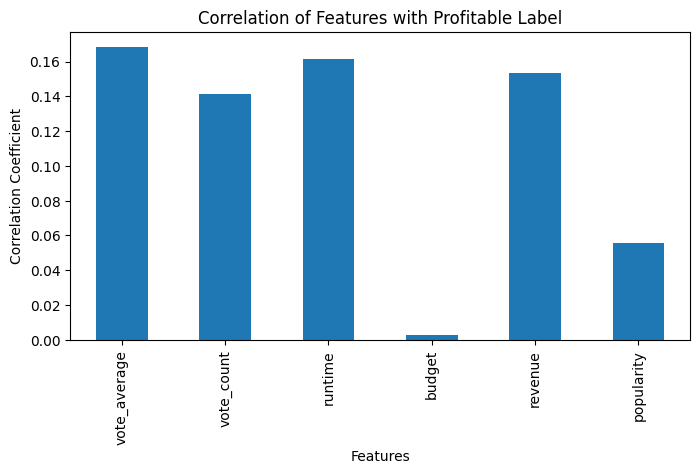


Correlation Table with Profitable Label:
vote_average    0.168614
runtime         0.161334
revenue         0.153113
vote_count      0.141546
popularity      0.055917
budget          0.002963
Name: profitable_numeric, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# Convert label to numeric for correlation
movies['profitable_numeric'] = movies['profitable_label'].map({'profitable': 0, 'not-profitable': 1})

# Identify numeric columns to correlate with the label
numeric_cols = ['vote_average', 'vote_count', 'runtime', 'budget', 'revenue', 'popularity']

numeric_cols_with_label = numeric_cols + ['profitable_numeric']
corr_matrix = movies[numeric_cols_with_label].corr()
label_corr = corr_matrix['profitable_numeric'].drop('profitable_numeric')

# Plot as a bar chart
plt.figure(figsize=(8, 4))
label_corr.plot(kind='bar')
plt.title("Correlation of Features with Profitable Label")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.show()

print("\nCorrelation Table with Profitable Label:")
print(label_corr.sort_values(ascending=False))


In [67]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np

# Select some numeric features for proximity analysis
features_for_proximity = ['vote_average', 'vote_count', 'runtime', 'budget', 'revenue', 'popularity']

# Drop rows with missing values in these columns to simplify
movies_prox = movies.dropna(subset=features_for_proximity).copy()

# SAMPLE
sample_size = 10
movies_sample = movies_prox.sample(n=sample_size, random_state=42)
X_original = movies_sample[features_for_proximity].values

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X_original)
scaler_zscore = StandardScaler()
X_zscore = scaler_zscore.fit_transform(X_original)

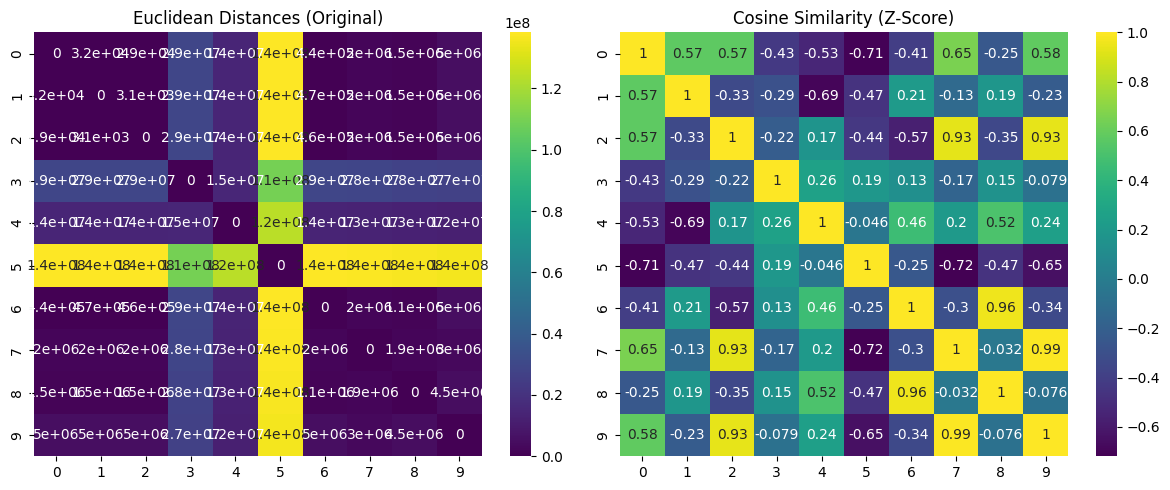

In [70]:
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Euclidean distances (original)
dist_original = euclidean_distances(X_original)

dist_minmax = euclidean_distances(X_minmax)
sim_zscore = cosine_similarity(X_zscore)


# Heatmap of distance or similarity
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(dist_original, ax=axs[0], cmap="viridis", annot=True)
axs[0].set_title("Euclidean Distances (Original)")

sns.heatmap(sim_zscore, ax=axs[1], cmap="viridis", annot=True)
axs[1].set_title("Cosine Similarity (Z-Score)")

plt.tight_layout()
plt.show()


In [60]:
from sklearn.metrics import accuracy_score
import numpy as np

# Convert label to 0/1, not profitable being the 1
movies['profitable_numeric'] = movies['profitable_label'].map({'profitable': 0, 'not-profitable': 1})
y = movies['profitable_numeric'].dropna()

# 1. Majority Class Baseline
majority_class = y.value_counts().idxmax()  # 0 or 1
y_pred_majority = np.full_like(y, majority_class)
majority_acc = accuracy_score(y, y_pred_majority)

# 2. Random Baseline
y_pred_random = np.random.randint(0, 2, size=len(y))
random_acc = accuracy_score(y, y_pred_random)

print(f"Majority Class Baseline Accuracy: {majority_acc:.2f}")
print(f"Random Baseline Accuracy: {random_acc:.2f}")


Majority Class Baseline Accuracy: 0.73
Random Baseline Accuracy: 0.50
